### Mashiur Rahman 

### Assignment 7: House Price Prediction Using Boston Housing Data

## **Assignment Supervised machine Learning - Regression**

### **_House Price Prediction Using Bolton Housing Data_**
This dataset provides information about house prices in Bolton. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "Boston Housing Dataset" from sklearn. The regression model will either be a Decision Tree or Random Forest regressor.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (Bolton Housing):

* CRIM: Crime rate by town
* ZN: Proportion of residential land zoned for large lots
* INDUS: Proportion of non-retail business acres per town
* CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX: Nitric oxide concentration (parts per 10 million)
* RM: Average number of rooms per dwelling
* AGE: Proportion of owner-occupied units built before 1940
* DIS: Weighted distances to five Boston employment centers
* RAD: Index of accessibility to radial highways
* TAX: Full-value property tax rate per `$10,000`
* PTRATIO: Pupil-teacher ratio by town
* B: Proportion of Black population
* LSTAT: Percentage of lower status of the population
* MEDV (Target): Median value of owner-occupied homes in `$1,000s`



**Dataset is from sklearn Datasets**

## 1. Imports:

In [1]:
# Import libraries for data handling
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Remove unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## 2. Data Collection and Loading:

In [2]:
# Load the Boston Housing dataset from sklearn
boston = fetch_openml(
    name="boston",
    version=1,
    as_frame=True,
    parser="auto"
)

# Convert the dataset into a pandas DataFrame
df = boston.frame.copy()

# Rename the target column as MEDV
df.rename(columns={"MEDV": "MEDV"}, inplace=True)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (506, 14)


## 3. Quick Check of Data:

In [3]:
# Display the first five rows
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
# Display the feature names
print("Features:")
print(list(df.columns[:-1]))

# Display the target variable
print("\nTarget variable:")
print(df.columns[-1])

# Display the structure and data types
print("\nDataset information:")
df.info()

Features:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

Target variable:
MEDV

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 48.6 KB


In [5]:
# Display descriptive statistics
df.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


### Identification of Variables

The target variable is **MEDV**, which represents the median house value in thousands of dollars.
Most of the independent variables are continuous numerical variables. **CHAS** is a categorical binary variable because it contains 0 or 1. **RAD** is an index-based discrete variable.

## 4. EDA and Data Preprocessing:

In [6]:
# Convert every column to a numeric data type
df = df.apply(pd.to_numeric, errors="coerce")

# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values in each column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Number of duplicate rows: 0


In [7]:
# Remove duplicate rows, if any
df = df.drop_duplicates()

# Fill missing numerical values with their median
df = df.fillna(df.median(numeric_only=True))

# Confirm that the data is clean
print("Total missing values:", df.isnull().sum().sum())
print("Dataset shape after preprocessing:", df.shape)

Total missing values: 0
Dataset shape after preprocessing: (506, 14)


### Scatter Plot Between RM and MEDV

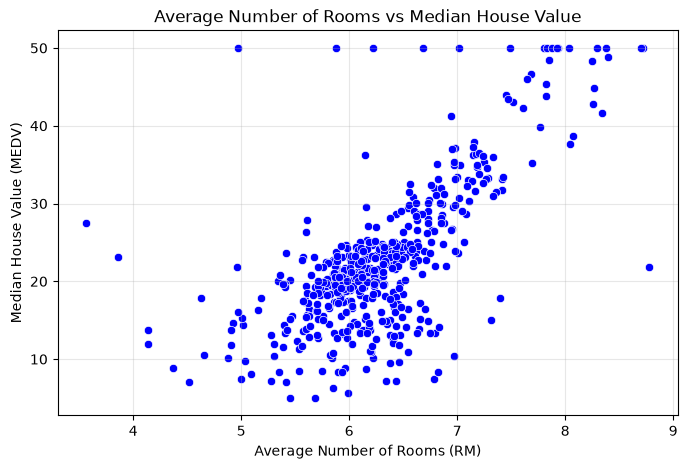

In [8]:
# Visualize the relationship between RM and MEDV
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="RM",
    y="MEDV",
    color="blue"
)

plt.title("Average Number of Rooms vs Median House Value")
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.grid(alpha=0.3)
plt.show()

### Function for Creating Scatter Plots

In [9]:
# Create a function to plot multiple features against the target
def create_scatter_plots(data, features, target):
    
    rows = (len(features) + 1) // 2
    
    plt.figure(figsize=(12, 5 * rows))
    
    for position, feature in enumerate(features, start=1):
        plt.subplot(rows, 2, position)
        
        sns.scatterplot(
            data=data,
            x=feature,
            y=target,
            color="teal"
        )
        
        plt.title(f"{feature} vs {target}")
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### Relationships Between Selected Features and MEDV

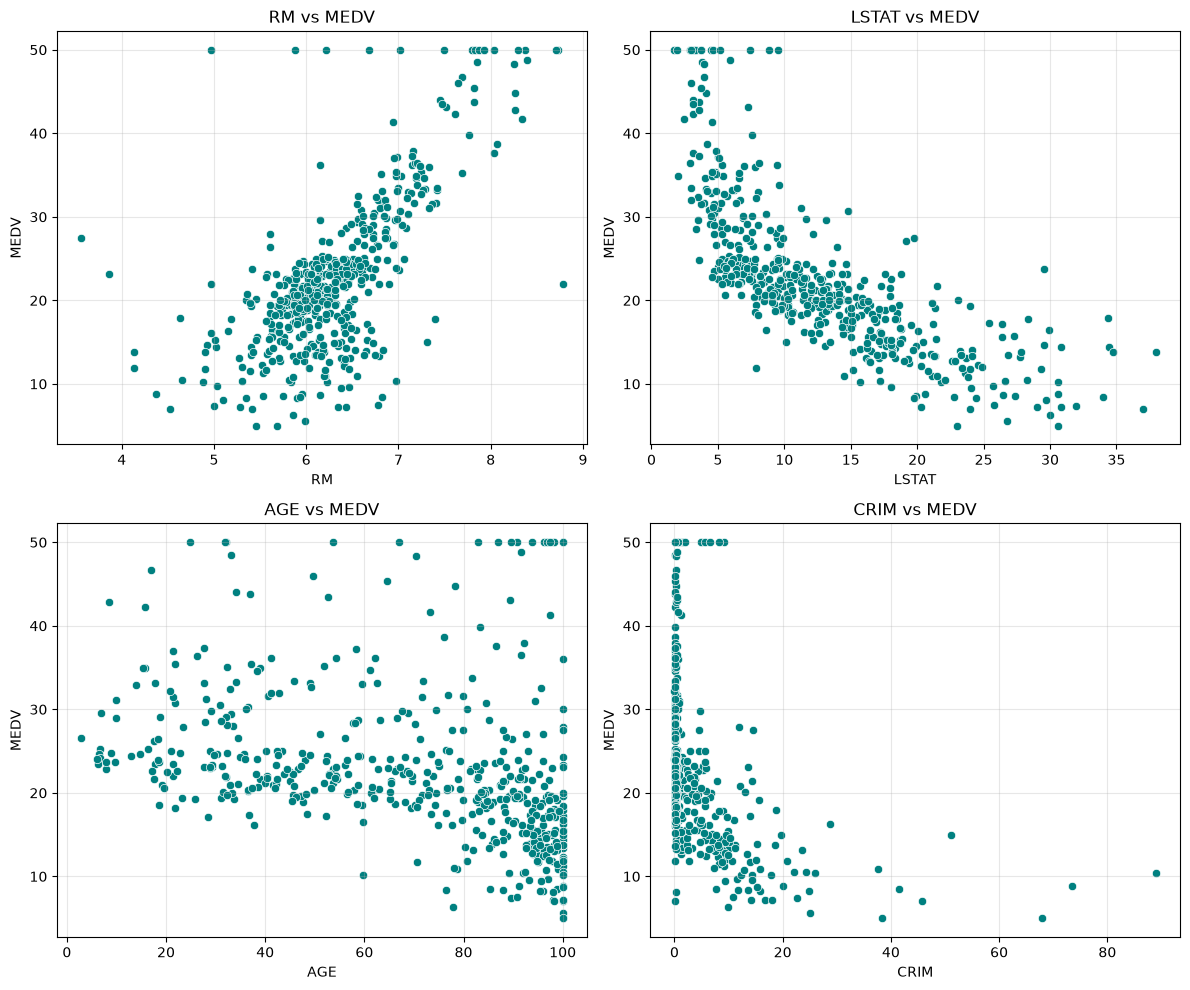

In [10]:
# Select features for visualization
selected_features = ["RM", "LSTAT", "AGE", "CRIM"]

# Use the function to create scatter plots
create_scatter_plots(
    data=df,
    features=selected_features,
    target="MEDV"
)

## 5. ML Model Training:

In [12]:
# Separate the independent features and target variable
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

# Split the data: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (404, 13)
Testing feature shape: (102, 13)
Training target shape: (404,)
Testing target shape: (102,)


### Random Forest Regression Model

In [13]:
# Create a Random Forest regression model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Random Forest model training completed.")

Random Forest model training completed.


## 6. Model Evaluation:

In [14]:
# Make predictions using the test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r_squared = r2_score(y_test, y_pred)

print("Initial Model Results")
print("---------------------")
print("Mean Squared Error:", round(mse, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R-squared:", round(r_squared, 2))

Initial Model Results
---------------------
Mean Squared Error: 7.88
Root Mean Squared Error: 2.81
R-squared: 0.89


### Actual Values Compared with Predicted Values

In [15]:
# Create a comparison table
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
173,23.6,22.890
274,32.4,30.694
491,13.6,16.342
72,22.8,23.528
452,16.1,16.796
76,20.0,21.368
316,17.8,19.314
140,14.0,15.660
471,19.6,21.071
500,16.8,21.021


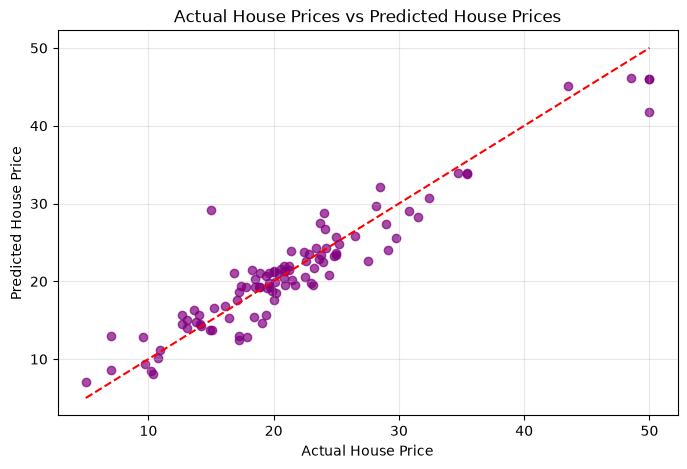

In [16]:
# Plot actual values against predicted values
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    color="purple",
    alpha=0.7
)

# Add a perfect-prediction reference line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--"
)

plt.title("Actual House Prices vs Predicted House Prices")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.grid(alpha=0.3)
plt.show()

### Parameter Tuning

In [18]:
# Define different parameter combinations
parameter_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=parameter_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train and tune the model
grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [19]:
# Make predictions using the tuned model
tuned_predictions = best_model.predict(X_test)

# Evaluate the tuned model
tuned_mse = mean_squared_error(y_test, tuned_predictions)
tuned_rmse = np.sqrt(tuned_mse)
tuned_r_squared = r2_score(y_test, tuned_predictions)

print("Tuned Model Results")
print("-------------------")
print("Root Mean Squared Error:", round(tuned_rmse, 2))
print("R-squared:", round(tuned_r_squared, 2))

Tuned Model Results
-------------------
Root Mean Squared Error: 3.02
R-squared: 0.88


## 7. Model Prediction:

In [20]:
# Create a new set of feature inputs
new_house = pd.DataFrame(
    [[
        0.20,    # CRIM
        12.50,   # ZN
        7.07,    # INDUS
        0,       # CHAS
        0.50,    # NOX
        6.50,    # RM
        68.00,   # AGE
        4.00,    # DIS
        2,       # RAD
        250,     # TAX
        18.00,   # PTRATIO
        390.00,  # B
        10.00    # LSTAT
    ]],
    columns=X.columns
)

# Display the new house data
new_house

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.2,12.5,7.07,0,0.5,6.5,68.0,4.0,2,250,18.0,390.0,10.0


In [21]:
# Predict the house price using the tuned model
predicted_price = best_model.predict(new_house)

print(
    "Predicted house price: $",
    round(predicted_price[0] * 1000, 2)
)

Predicted house price: $ 22799.69


### Conclusion

In [ ]:
A Random Forest regression model was developed to predict median house prices using the Boston Housing Dataset. The model was evaluated using RMSE and R-squared. Parameter tuning was also performed to find a better combination of model settings. Finally, the tuned model was used to predict the price of a new house.

In [ ]:


# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
# Example: import pandas as pd
# Add your imports here:


# --- Data Collection and Loading ---
# TODO: Load the 'Boston Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Hint: Use `load_boston()` from `sklearn.datasets`

# Load dataset and convert to DataFrame:

# Add your code here:


# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
# Hint: Use `.head()` to inspect the first few rows.

# Add your code here:


# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.

# Add your code here:


# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.

# Add your code here:


# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable.
# Example: Use `plt.scatter()` to visualize the relationship between features like 'RM' (average number of rooms) and the target ('MEDV').

# Add your code here:


# TODO: Create a function to automate scatter plots for all features vs the target variable.
# Hint: The function should loop over a list of features and plot scatter plots for each.

# Define your function here:


# TODO: Use the function to visualize the relationships between multiple features and the target variable.
# Example: ['RM', 'LSTAT', 'AGE', 'CRIM']
# Target: 'MEDV'

# Add your code here:


# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.

# Define X (features) and y (target) and perform the train-test split:


# TODO: Choose an appropriate regression model: Decision Tree or Random Forest.
# Hint: Use either `DecisionTreeRegressor` or `RandomForestRegressor` from `sklearn.tree` or `sklearn.ensemble`.

# Define your regression model here:


# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.

# Add your code here:


# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.

# Perform parameter tuning on the model if needed to improve the performance of your model.

# Add your parameter tuning code here:

# Predict on the test set and calculate the evaluation metrics:


# --- Model Prediction ---
# TODO: Predict house prices from a new set of feature inputs.
# Example new data: Use hypothetical or randomly generated values for the features.
#
# Example new data: CRIM = 0.2, ZN = 12.5, INDUS = 7.07, CHAS = 0, NOX = 0.5, RM = 6.5, AGE = 68, DIS = 4.0, RAD = 2, TAX = 250, PTRATIO = 17, B = 400, LSTAT = 12

# Add your prediction code here:



